## 1. Load Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [3]:
train_original = pd.read_csv("titanic_train.csv")
test_original  = pd.read_csv("titanic_test.csv")
train = train_original.copy()
test = test_original.copy()

In [5]:
print("Train dataset:")
display(train.head())

print("Test dataset:")
display(test.head())

Train dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Test dataset:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 2. Data Quality Assessment
- Converted categorical columns (Sex, Embarked) to appropriate formats.
- Removed irrelevant columns (Name, Ticket, Cabin, PassengerId).

In [12]:
print("Train data types: \n")
display(train.dtypes)

print(" \nTest data types: \n")
display(test.dtypes)

Train data types: 



PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

 
Test data types: 



PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [13]:
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})

In [14]:
train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

In [15]:
print("Train dataset:")
display(train.head())

print("Test dataset:")
display(test.head())

Train dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,True


Test dataset:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NaN,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NaN,False,True
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NaN,True,False
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NaN,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NaN,False,True


In [16]:
print("Train data types: \n")
display(train.dtypes)

print(" \nTest data types: \n")
display(test.dtypes)

Train data types: 



PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked_Q        bool
Embarked_S        bool
dtype: object

 
Test data types: 



PassengerId      int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked_Q        bool
Embarked_S        bool
dtype: object

In [17]:
train = train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test = test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [18]:
print("Train data types: \n")
display(train.dtypes)

print(" \nTest data types: \n")
display(test.dtypes)

Train data types: 



Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object

 
Test data types: 



Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object

## 3. Handling Missing Values
- Identified missing values using df.isna().sum().

- Filled missing values in Age using median imputation.

- Dropped rows with missing Fare values due to their small number.

In [19]:
print("Train missing values:")
display(train.isna())

print("Test missing values:")
display(test.isna())

Train missing values:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False
887,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False
889,False,False,False,False,False,False,False,False,False


Test missing values:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
413,False,False,True,False,False,False,False,False
414,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False
416,False,False,True,False,False,False,False,False


In [20]:
print("Train missing values:")
display(train.isna().sum())

print("Test missing values:")
display(test.isna().sum())

Train missing values:


Survived        0
Pclass          0
Sex             0
Age           177
SibSp           0
Parch           0
Fare            0
Embarked_Q      0
Embarked_S      0
dtype: int64

Test missing values:


Pclass         0
Sex            0
Age           86
SibSp          0
Parch          0
Fare           1
Embarked_Q     0
Embarked_S     0
dtype: int64

In [42]:
# Handle missing values in the 'Age' column using median imputation
# Median is used because it is robust to outliers and suitable for numerical data
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(test['Age'].median())

# Remove rows with missing values in the 'Fare' column
# This is acceptable since only a small number of records are affected
test = test.dropna(subset=['Fare'])

In [28]:
# compare shapes
print('train data before drop: ', train_original.shape)
print('train data after drop: ', train.shape)

print('\ntest data before drop: ', test_original.shape)
print('test data after drop: ', test.shape)

# check missing
print("\nTrain missing values:")
display(train.isna().sum())

print("\nTest missing values:")
display(test.isna().sum())

train data before drop:  (891, 12)
train data after drop:  (891, 9)

test data before drop:  (418, 11)
test data after drop:  (417, 8)

Train missing values:


Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64


Test missing values:


Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64

## 4. Handling Outliers
- Detected outliers using boxplots in the Age, Fare feature.
- Applied the percentile capping method.
- Reduced the impact of outliers while maintaining the overall distribution.

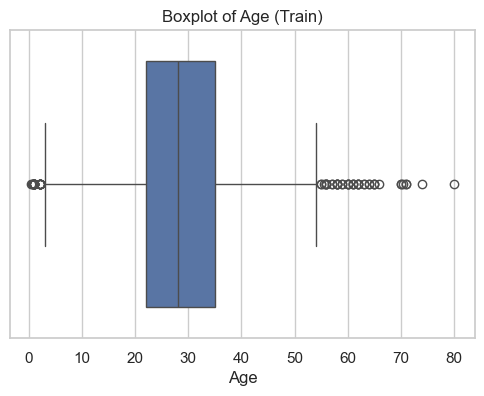

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train['Age'])

plt.title('Boxplot of Age (Train)')
plt.show()

In [30]:
Q1 = train['Age'].quantile(0.25)
Q3 = train['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[(train['Age'] < lower) | (train['Age'] > upper)]
outliers.head(15)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
7,0,3,0,2.00,3,1,21.0750,False,True
11,1,1,1,58.00,0,0,26.5500,False,True
15,1,2,1,55.00,0,0,16.0000,False,True
16,0,3,0,2.00,4,1,29.1250,True,False
33,0,2,0,66.00,0,0,10.5000,False,True
54,0,1,0,65.00,0,1,61.9792,False,False
78,1,2,0,0.83,0,2,29.0000,False,True
94,0,3,0,59.00,0,0,7.2500,False,True
96,0,1,0,71.00,0,0,34.6542,False,False
116,0,3,0,70.50,0,0,7.7500,True,False


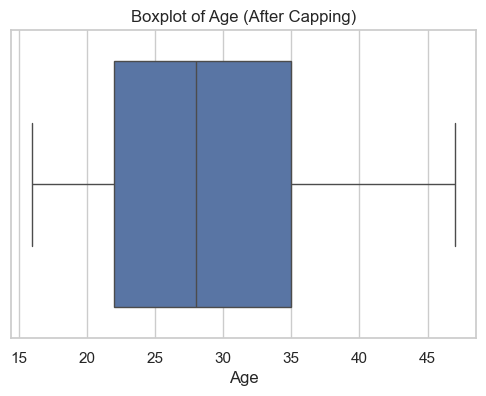

In [38]:
lower_cap = train['Age'].quantile(0.10)
upper_cap = train['Age'].quantile(0.90)

train_capped = train.copy()
train_capped['Age'] = train_capped['Age'].clip(lower_cap, upper_cap)

plt.figure(figsize=(6,4))
sns.boxplot(x=train_capped['Age'])

plt.title('Boxplot of Age (After Capping)')
plt.show()

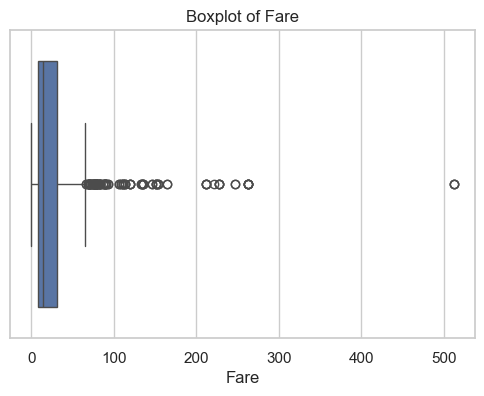

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x=train['Fare'])

plt.title('Boxplot of Fare')
plt.show()

In [35]:
Q1 = train['Fare'].quantile(0.25)
Q3 = train['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[(train['Fare'] < lower) | (train['Fare'] > upper)]
outliers.head(15)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
1,1,1,1,38.0,1,0,71.2833,False,False
27,0,1,0,19.0,3,2,263.0000,False,True
31,1,1,1,28.0,1,0,146.5208,False,False
34,0,1,0,28.0,1,0,82.1708,False,False
52,1,1,1,49.0,1,0,76.7292,False,False
61,1,1,1,38.0,0,0,80.0000,False,False
62,0,1,0,45.0,1,0,83.4750,False,True
72,0,2,0,21.0,0,0,73.5000,False,True
88,1,1,1,23.0,3,2,263.0000,False,True
102,0,1,0,21.0,0,1,77.2875,False,True


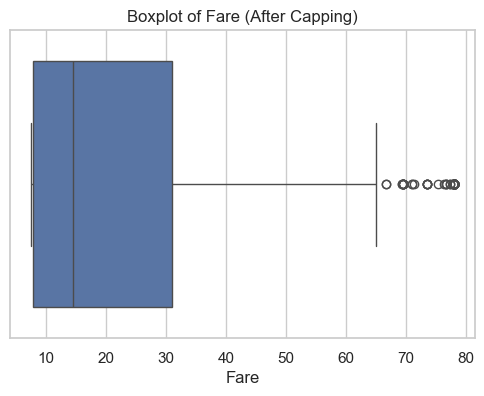

In [37]:
lower_cap = train['Fare'].quantile(0.10)
upper_cap = train['Fare'].quantile(0.90)

train_capped = train.copy()
train_capped['Fare'] = train_capped['Fare'].clip(lower_cap, upper_cap)

plt.figure(figsize=(6,4))
sns.boxplot(x=train_capped['Fare'])

plt.title('Boxplot of Fare (After Capping)')
plt.show()

**NOTE: Complete removal of outliers is not always necessary. reducing their influence is often sufficient for improving model performance**

## 5. Data Transformation – Normalization
- Applied normalization to numerical features (Age and Fare).
- Used Min-Max scaling to rescale values between 0 and 1.
- Used Z-score standardization to center data around mean 0 and standard deviation 1.

### 1. Min-Max Normalization

In [39]:
from sklearn.preprocessing import MinMaxScaler

train_minmax = train[['Age', 'Fare']].copy()

# scaler
scaler = MinMaxScaler()

# apply
train_minmax[['Age', 'Fare']] = scaler.fit_transform(train_minmax)

train_minmax.head()

,Age,Fare
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


### 2. Z-Score Normalization

In [40]:
from sklearn.preprocessing import StandardScaler

train_zscore = train[['Age', 'Fare']].copy()

# scaler
scaler = StandardScaler()

# apply
train_zscore[['Age', 'Fare']] = scaler.fit_transform(train_zscore)

train_zscore.head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


## 6. Data Reduction
- Evaluated correlation between numerical features (Age and Fare).
- Found weak correlation between features.
- Decided not to apply PCA to avoid unnecessary information loss.

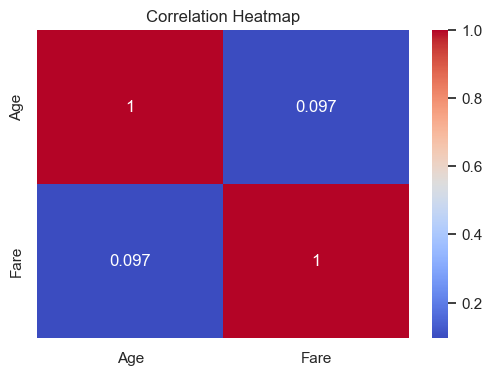

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(train[['Age', 'Fare']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**NOTE: The correlation between numerical features (Age and Fare) was found to be weak (close to 0). Therefore, PCA was not applied, as the features do not contain redundant information.**

In [43]:
train.to_csv("titanic_train_cleaned.csv", index=False)
test.to_csv("titanic_test_cleaned.csv", index=False)